### 1. Mount Google Drive
This cell mounts Google Drive to `/content/drive`, which will be used by the following cells.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Test Loading an Image
This cell looks for the first `jpg/jpeg` image in `Colab/dataset/2077/2077_scene1`, prints its path, and displays it.


Loaded image: /content/drive/MyDrive/Colab/dataset/2077/2077_scene1/000005.jpg
Found 9 JPG image(s) in total.


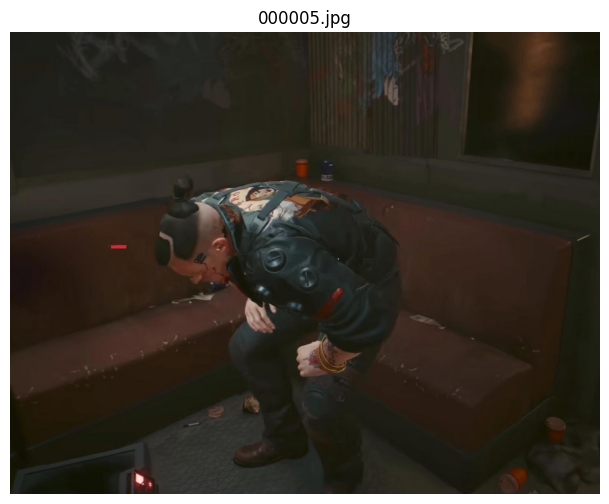

In [3]:
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt

candidate_dirs = [
    Path('/content/drive/MyDrive/Colab/dataset/2077/2077_scene1'),
    Path('/content/drive/My Drive/Colab/dataset/2077/2077_scene1'),
]
image_dir = next((path for path in candidate_dirs if path.exists()), candidate_dirs[0])

if not image_dir.exists():
    raise FileNotFoundError(f'Directory not found: {image_dir}')

jpg_files = sorted(
    list(image_dir.glob('*.jpg'))
    + list(image_dir.glob('*.JPG'))
    + list(image_dir.glob('*.jpeg'))
    + list(image_dir.glob('*.JPEG'))
)

if not jpg_files:
    raise FileNotFoundError(f'No JPG images found in: {image_dir}')

image_path = jpg_files[0]
print(f'Loaded image: {image_path}')
print(f'Found {len(jpg_files)} JPG image(s) in total.')

image = Image.open(image_path).convert('RGB')
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title(image_path.name)
plt.show()


### 3. Check Runtime Hardware
This cell prints the current Colab runtime CPU model, CPU core count, and GPU name, memory, and driver version.


In [4]:
import os
import platform
import subprocess


def get_cpu_model():
    cpuinfo_path = '/proc/cpuinfo'
    if os.path.exists(cpuinfo_path):
        with open(cpuinfo_path, 'r') as f:
            for line in f:
                if 'model name' in line:
                    return line.split(':', 1)[1].strip()
    return platform.processor() or platform.machine()


print(f'CPU model: {get_cpu_model()}')
print(f'CPU cores: {os.cpu_count()}')

try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total,driver_version', '--format=csv,noheader'],
        capture_output=True,
        text=True,
        check=True,
    )
    gpus = [line.strip() for line in result.stdout.splitlines() if line.strip()]

    if gpus:
        print('GPU(s):')
        for idx, gpu in enumerate(gpus):
            print(f'  {idx}: {gpu}')
    else:
        print('GPU: detected, but no details were returned by nvidia-smi.')
except FileNotFoundError:
    print('GPU: nvidia-smi not found. This runtime is likely CPU-only.')
except subprocess.CalledProcessError as e:
    print('GPU: nvidia-smi could not query a GPU.')
    if e.stderr.strip():
        print(e.stderr.strip())


CPU model: Intel(R) Xeon(R) CPU @ 2.00GHz
CPU cores: 2
GPU(s):
  0: Tesla T4, 15360 MiB, 580.82.07
